# Session 9, Notebook 4: Build a PINN from Scratch

**Course:** Deep Learning for Solving Dynamic Models, University of Padova, 23-24 September 2026
**Session:** Day 2, 15:10-16:00, Physics-informed neural networks: applications and hands-on
**Slides:** `09_PINNs_Applications.pdf`
**Notebook role:** exercise, with fill-in-the-blank cells
**Author:** Simon Scheidegger (HEC, University of Lausanne)

> **Hands-on, 12 minutes in class.** The cells marked `TODO` are yours. A worked solution follows
> each task in this notebook, so try first, then compare. The `TODO` cells run as they are (they do
> nothing), so the notebook also executes top to bottom for anyone who wants to read it later.

You will implement a physics-informed neural network (PINN) for the ordinary differential equation

$$u''(x) + u(x) = 0, \qquad x \in [0, \pi/2], \qquad u(0) = 0, \quad u(\pi/2) = 1 .$$

The solution is $u(x) = \sin x$: it satisfies the equation, since $u'' = -\sin x$, and both
boundary values. The three ingredients are the ones from the lecture: a network for $u$, automatic
differentiation for $u''$, and a loss made of the residual at collocation points plus a boundary penalty.

| Task | Minutes | What you write |
|:--|:--:|:--|
| 1 | 3 | The network |
| 2 | 4 | The residual $u'' + u$ by `torch.autograd.grad` |
| 3 | 5 | The training loop |
| 4 | given | Evaluation against $\sin x$ |
| Bonus A | at home | Hard boundary conditions |
| Bonus B | at home | Why the interval $[0,\pi]$ with $u(0)=u(\pi)=0$ does not work |

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
torch.set_default_dtype(torch.float64)
plt.rcParams.update({"font.size": 12, "axes.grid": True, "grid.alpha": 0.3})

X_END = np.pi / 2          # right end of the interval
U_END = 1.0                # boundary value there, u(pi/2) = sin(pi/2) = 1

## Task 1: the network (3 min)

A multilayer perceptron with one input $x$, two hidden layers of 32 units with `tanh`, and one
output $u(x)$. Use `tanh`, not ReLU: the loss needs $u''$, and the second derivative of a ReLU
network is zero almost everywhere.

In [2]:
class PINN(nn.Module):
    def __init__(self, n_hidden=32):
        super().__init__()
        # TODO: three linear layers, 1 -> n_hidden -> n_hidden -> 1
        pass

    def forward(self, x):
        # TODO: tanh after the first two layers, no activation on the output
        pass

### Solution

In [3]:
class PINN(nn.Module):
    def __init__(self, n_hidden=32):
        super().__init__()
        self.fc1 = nn.Linear(1, n_hidden)
        self.fc2 = nn.Linear(n_hidden, n_hidden)
        self.fc3 = nn.Linear(n_hidden, 1)

    def forward(self, x):
        h = torch.tanh(self.fc1(x))
        h = torch.tanh(self.fc2(h))
        return self.fc3(h)

## Task 2: the residual (4 min)

The residual is $R(x) = u''(x) + u(x)$. Two calls to `torch.autograd.grad` give $u'$ and then $u''$.
Both need `create_graph=True`: the first so that $u'$ can be differentiated again, the second so
that the training step can backpropagate through $u''$.

In [4]:
def pde_residual(model, x):
    """Return R(x) = u''(x) + u(x) at the points x (shape [N, 1])."""
    x = x.clone().requires_grad_(True)
    u = model(x)
    # TODO: u_x  = torch.autograd.grad(u,   x, grad_outputs=torch.ones_like(u),   create_graph=True)[0]
    # TODO: u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]
    # TODO: return u_xx + u
    pass

### Solution

In [5]:
def pde_residual(model, x):
    """Return R(x) = u''(x) + u(x) at the points x (shape [N, 1])."""
    x = x.clone().requires_grad_(True)
    u = model(x)
    u_x  = torch.autograd.grad(u,   x, grad_outputs=torch.ones_like(u),   create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]
    return u_xx + u

## Task 3: the training loop (5 min)

The loss is

$$\mathcal{L} = \frac{1}{N}\sum_{i=1}^{N} R(x_i)^2
  \;+\; \lambda\,\Bigl[u_\theta(0)^2 + \bigl(u_\theta(\pi/2) - 1\bigr)^2\Bigr],
  \qquad \lambda = 10,$$

with $N = 256$ collocation points drawn uniformly on $[0, \pi/2]$, fresh at every iteration.
Train with Adam at learning rate $10^{-3}$ for 3,000 iterations.

In [6]:
model = PINN(n_hidden=32)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
n_iters, lam = 3000, 10.0
x0, x1 = torch.zeros(1, 1), torch.full((1, 1), X_END)
loss_history = []

for it in range(1, n_iters + 1):
    x_int = torch.rand(256, 1) * X_END
    # TODO: loss_pde = mean of pde_residual(model, x_int) ** 2
    # TODO: loss_bc  = model(x0) ** 2 + (model(x1) - U_END) ** 2
    # TODO: loss = loss_pde + lam * loss_bc
    # TODO: optimizer.zero_grad(); loss.backward(); optimizer.step()
    # TODO: loss_history.append(loss.item())
    pass

### Solution

In [7]:
torch.manual_seed(42)
model = PINN(n_hidden=32)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
n_iters, lam = 3000, 10.0
x0, x1 = torch.zeros(1, 1), torch.full((1, 1), X_END)
loss_history = []

for it in range(1, n_iters + 1):
    x_int = torch.rand(256, 1) * X_END
    loss_pde = torch.mean(pde_residual(model, x_int) ** 2)
    loss_bc = (model(x0) ** 2 + (model(x1) - U_END) ** 2).squeeze()
    loss = loss_pde + lam * loss_bc
    optimizer.zero_grad(); loss.backward(); optimizer.step()
    loss_history.append(loss.item())
    if it % 500 == 0 or it == 1:
        print(f"iter {it:5d}  loss {loss.item():.3e}  (residual {loss_pde.item():.3e}, boundary {loss_bc.item():.3e})")

iter     1  loss 1.686e+01  (residual 2.899e-02, boundary 1.683e+00)


iter   500  loss 5.766e-02  (residual 5.665e-02, boundary 1.012e-04)


iter  1000  loss 4.288e-04  (residual 4.269e-04, boundary 1.919e-07)


iter  1500  loss 4.186e-05  (residual 4.169e-05, boundary 1.630e-08)


iter  2000  loss 3.715e-05  (residual 3.701e-05, boundary 1.461e-08)


iter  2500  loss 2.982e-05  (residual 2.959e-05, boundary 2.334e-08)


iter  3000  loss 1.930e-05  (residual 1.866e-05, boundary 6.368e-08)


## Task 4: evaluate against $\sin x$ (given)

A small loss says the residual is small at the sampled points. The comparison with the exact
solution is what says the answer is right.

soft boundary conditions: max |u - sin x| = 3.21e-04, mean = 1.13e-04


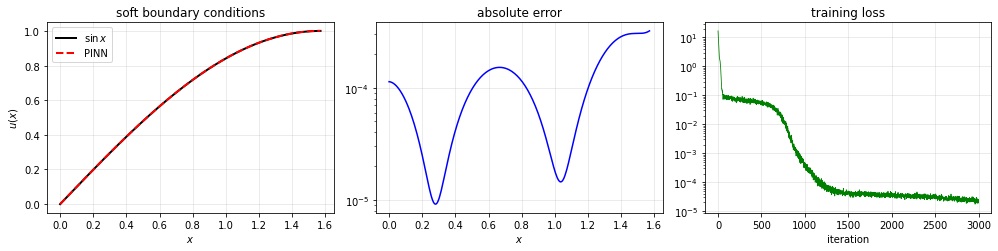

In [8]:
def evaluate(u_of_x, title):
    x_eval = torch.linspace(0, X_END, 300).reshape(-1, 1)
    with torch.no_grad():
        u_pred = u_of_x(x_eval).numpy().ravel()
    x_np = x_eval.numpy().ravel(); u_exact = np.sin(x_np); err = np.abs(u_pred - u_exact)
    print(f"{title}: max |u - sin x| = {err.max():.2e}, mean = {err.mean():.2e}")
    fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
    axes[0].plot(x_np, u_exact, "k-", lw=2, label=r"$\sin x$")
    axes[0].plot(x_np, u_pred, "r--", lw=2, label="PINN")
    axes[0].set_xlabel("$x$"); axes[0].set_ylabel("$u(x)$"); axes[0].legend(); axes[0].set_title(title)
    axes[1].semilogy(x_np, err, "b-"); axes[1].set_xlabel("$x$"); axes[1].set_title("absolute error")
    axes[2].semilogy(loss_history, "g-", lw=0.8); axes[2].set_xlabel("iteration"); axes[2].set_title("training loss")
    fig.tight_layout(); plt.show()
    return err.max()

err_soft = evaluate(model, "soft boundary conditions")

## Bonus A: hard boundary conditions (at home)

Write $\tilde u(x) = A(x) + B(x)\,N_\theta(x)$ with $A(x) = 2x/\pi$, which takes the two boundary
values, and $B(x) = x\,(\pi/2 - x)$, which vanishes at both ends. Then $\tilde u(0) = 0$ and
$\tilde u(\pi/2) = 1$ whatever the network outputs, and the loss is the residual alone.

final residual loss 8.557e-07
hard boundary conditions: max |u - sin x| = 6.70e-05, mean = 4.19e-05


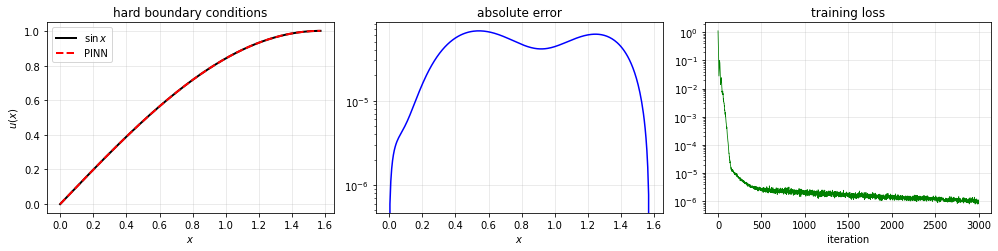

In [9]:
def u_hard(net, x):
    return (2.0 / np.pi) * x + x * (X_END - x) * net(x)

def residual_hard(net, x):
    x = x.clone().requires_grad_(True)
    u = u_hard(net, x)
    u_x  = torch.autograd.grad(u,   x, grad_outputs=torch.ones_like(u),   create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]
    return u_xx + u

torch.manual_seed(42)
net_hard = PINN(n_hidden=32)
optimizer = torch.optim.Adam(net_hard.parameters(), lr=1e-3)
loss_history = []
for it in range(1, n_iters + 1):
    x_int = torch.rand(256, 1) * X_END
    loss = torch.mean(residual_hard(net_hard, x_int) ** 2)
    optimizer.zero_grad(); loss.backward(); optimizer.step()
    loss_history.append(loss.item())
print(f"final residual loss {loss.item():.3e}")
err_hard = evaluate(lambda x: u_hard(net_hard, x), "hard boundary conditions")

## Bonus B: why the interval matters (at home)

The same equation on $[0, \pi]$ with $u(0) = u(\pi) = 0$ looks like the more natural exercise, and
$\sin x$ solves it too. But so does $c \sin x$ for every constant $c$, including $c = 0$. The loss
cannot tell them apart, and a network initialised near zero stays there: the loss goes to $10^{-6}$
and the answer is wrong by the full amplitude of $\sin x$. The problem is ill-posed, and no amount of
training fixes that. Check the equation you are solving before you train on it.

In [10]:
torch.manual_seed(42)
net_ill = PINN(n_hidden=32)
optimizer = torch.optim.Adam(net_ill.parameters(), lr=1e-3)
x_pi = torch.full((1, 1), np.pi)
for it in range(1, n_iters + 1):
    x_int = torch.rand(256, 1) * np.pi
    loss = torch.mean(pde_residual(net_ill, x_int) ** 2) + lam * (net_ill(x0) ** 2 + net_ill(x_pi) ** 2).squeeze()
    optimizer.zero_grad(); loss.backward(); optimizer.step()

x_eval = torch.linspace(0, np.pi, 300).reshape(-1, 1)
with torch.no_grad():
    u_ill = net_ill(x_eval).numpy().ravel()
print(f"ill-posed variant on [0, pi]: final loss {loss.item():.2e}, "
      f"max |u| = {np.abs(u_ill).max():.2e}, max |u - sin x| = {np.abs(u_ill - np.sin(x_eval.numpy().ravel())).max():.2f}")

ill-posed variant on [0, pi]: final loss 1.43e-06, max |u| = 6.51e-04, max |u - sin x| = 1.00


## Summary

1. A PINN turns a differential equation into a loss: the residual at collocation points, plus the
   boundary conditions, either as a penalty or built into the trial solution.
2. `torch.autograd.grad` with `create_graph=True` gives the derivatives, exactly, and lets the
   training step differentiate through them.
3. Read the error against the known solution, not the loss. Bonus B is the extreme case: a loss of
   $10^{-6}$ and a useless answer, because the boundary conditions did not pin the solution down.
4. The cake-eating HJB of `09_01` uses exactly these ingredients. The equation is nonlinear and comes
   from an optimisation, but the PINN machinery is the same.